# EDA Datos AFMP Pruevas Turbinas

In [124]:
# Librerias necesarias

import pandas as pd # Manejo de datos
import numpy  as np # Manejo de numeros
import matplotlib.pyplot as plt # Visualizacion
import seaborn as sns # Visuzalizacion
import os # Para uso de dotenv
from dotenv import load_dotenv # Variables de entorno

In [125]:
# Carga de los datos

load_dotenv(dotenv_path='/Users/juanv/Documents/Github/Despliegue-modelo-ANN-Turbinas-Hidraulicas/.env') # Cambia la ruta de tu .env

# Extraemos la base de datos del .env
Data = os.getenv('DB_USER')

# Para asi ver cada sheet del Excel
sheet_pedida = input('Ingresa el Sheet a analizar: ')

# Cargamos el dataset
try:
    # Creamos el dataframe 
    if Data and sheet_pedida is not None:
        df = pd.read_excel(Data, sheet_name=sheet_pedida)
    else:
        print('No existe el path')
except Exception as e:
    print(f'No existe la Sheet debes escribir el formato completo')

In [126]:
df.head(5)

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Sample Number,Tracking Value,Torque [Nm],Date,Time Elapsed,Angle,RPM,RPM_P,Power,Power [Watts]
2,0,-0.201324,0.201324,2025-07-10 09:54:43.582000,00:00:00,-110750.25,-802,802,0.016908,-16.908274
3,1,-0.201324,0.201324,2025-07-10 09:54:43.682000,00:00:00.100000,-111233.5,-805,805,0.016972,-16.971522
4,2,-0.19887,0.19887,2025-07-10 09:54:43.782000,00:00:00.200000,-111715.75,-803,803,0.016723,-16.722961


In [127]:
df.dropna(how='all', inplace=True) # Eliminamos filas nulas

# Renombramos columnas
df.columns = df.iloc[0] 
df = df[1:].reset_index(drop=True)

# Eliminamos columnas innecesarias
df.drop(columns=['RPM', 'Power'], inplace=True)

In [128]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 663 entries, 0 to 662
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Sample Number   663 non-null    object
 1   Tracking Value  663 non-null    object
 2   Torque [Nm]     663 non-null    object
 3   Date            663 non-null    object
 4   Time Elapsed    663 non-null    object
 5   Angle           663 non-null    object
 6   RPM_P           663 non-null    object
 7   Power [Watts]   663 non-null    object
dtypes: object(8)
memory usage: 41.6+ KB


In [129]:
# Valores absolutos de las columnas
df['RPM_P'] = df['RPM_P'].abs()
df['Power [Watts]'] = df['Power [Watts]'].abs()
df['Angle'] = df['Angle'].abs()
df['Torque [Nm]'] = df['Torque [Nm]'].abs()

# Convertimos a Numericos
df['Sample Number'] = pd.to_numeric(df['Sample Number'])
df['Tracking Value'] = pd.to_numeric(df['Tracking Value'])
df['Torque [Nm]'] = pd.to_numeric(df['Torque [Nm]'])
df['Angle'] = pd.to_numeric(df['Angle'])
df['RPM_P'] = pd.to_numeric(df['RPM_P'])
df['Power [Watts]'] = pd.to_numeric(df['Power [Watts]'])

#Convertimos a Fechas y tiempo
df['Date'] = pd.to_datetime(df['Date'])

In [130]:
df.head(5)

1,Sample Number,Tracking Value,Torque [Nm],Date,Time Elapsed,Angle,RPM_P,Power [Watts]
0,0,-0.201324,0.201324,2025-07-10 09:54:43.582,00:00:00,110750.25,802,16.908274
1,1,-0.201324,0.201324,2025-07-10 09:54:43.682,00:00:00.100000,111233.50,805,16.971522
2,2,-0.198870,0.198870,2025-07-10 09:54:43.782,00:00:00.200000,111715.75,803,16.722961
3,3,-0.198870,0.198870,2025-07-10 09:54:43.882,00:00:00.300000,112194.75,798,16.618833
4,4,-0.198101,0.198101,2025-07-10 09:54:43.982,00:00:00.400000,112669.00,790,16.388621


In [131]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
1,,,,,,,,
Sample Number,663.0,331.0,0.0,165.5,331.0,496.5,662.0,191.535897
Tracking Value,663.0,1.369746,-0.203128,-0.066773,1.581428,2.530269,3.184787,1.171061
Torque [Nm],663.0,1.468429,0.045234,0.202418,1.581428,2.530269,3.184787,1.044451
Date,663,2025-07-10 09:55:16.679708,2025-07-10 09:54:43.582000,2025-07-10 09:55:00.128500,2025-07-10 09:55:16.684000,2025-07-10 09:55:33.230000,2025-07-10 09:55:49.777000,NaN
Angle,663.0,82443.871418,262.5,41312.25,54952.75,133941.625,199972.5,57778.756927
RPM_P,663.0,474.20362,0.0,231.5,491.0,749.5,815.0,266.979823
Power [Watts],663.0,44.368736,0.0,16.686014,40.643247,74.959501,113.139855,28.545749


## Visualización de datos

Aqui realmente se hara algo bastante importante y es entender la forma en la que se relacionan y se distribuyen los datos. Para esto se pueden usar varias herramientas, pero una de las mas comunes es el uso de gráficos y diagramas.

Luego haremos un análisis de correlación para entender como se relacionan las variables entre si, y con la variable objetivo que es la potencia y usando un mapa de calor para visualizar estas relaciones.

Text(0, 0.5, '')

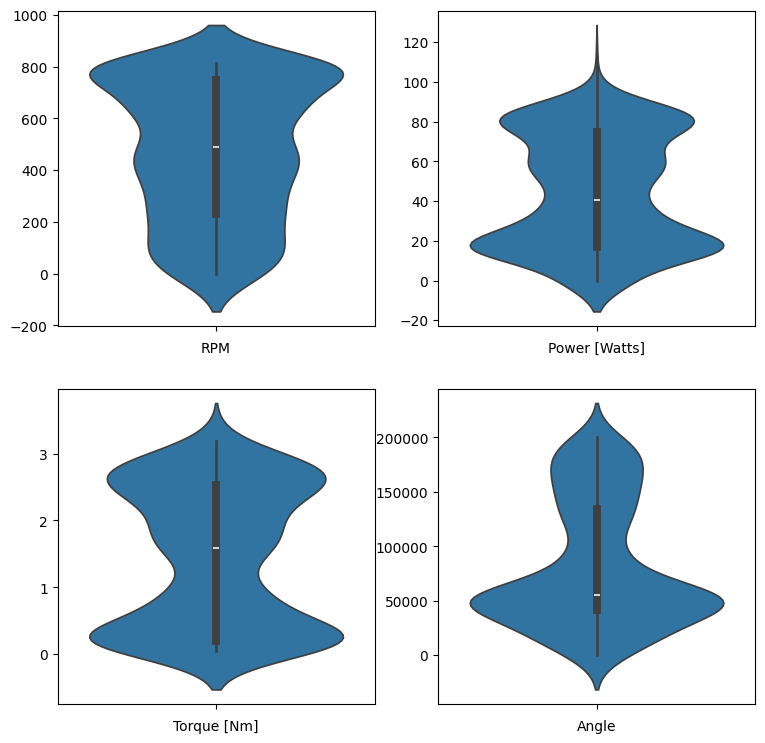

In [ ]:
# Primera grafica para ver los outliers de las variables de tipo features

figs, axes = plt.subplots(nrows=2, ncols=2, figsize=(10,9))
sns.violinplot(df['RPM_P'], ax=axes[0,0])
axes[0,0].set_xlabel('RPM')
axes[0,0].set_ylabel('')

sns.violinplot(df['Power [Watts]'], ax=axes[0,1])
axes[0,1].set_xlabel('Power [Watts]')
axes[0,1].set_ylabel('')

sns.violinplot(df['Torque [Nm]'], ax=axes[1,0])
axes[1,0].set_xlabel('Torque [Nm]')
axes[1,0].set_ylabel('')

sns.violinplot(df['Angle'], ax=axes[1,1])
axes[1,1].set_xlabel('Angle')
axes[1,1].set_ylabel('')

Text(0, 0.5, 'Power (Watts)')

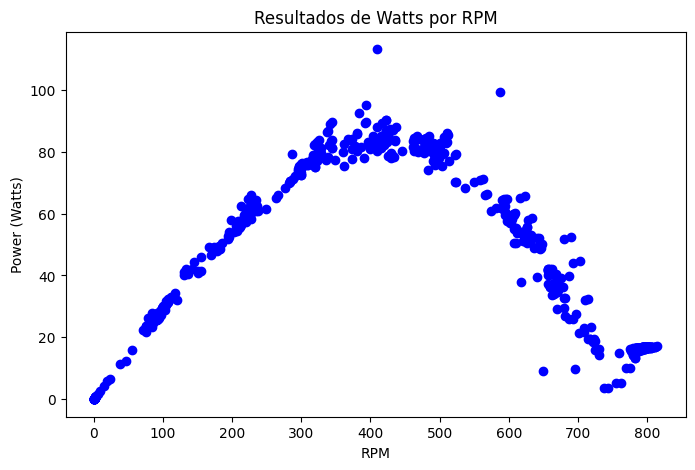

In [ ]:
# Esta grafica muestra la evolucion del Power en relacion de las RPM
# Cabe resaltar que aqui aun no se aplica feature_engeneering

plt.figure(figsize=(8,5))
plt.plot(df['RPM_P'], df['Power [Watts]'], marker='o', linestyle='', color='b')
plt.title('Resultados de Watts por RPM')
plt.xlabel('RPM')
plt.ylabel('Power (Watts)')

## Feature Engineering 
 
Como se evidencia en la grafica anterior hay muchos valores atipicos que pueden molestar a nuestro modelo mas adelante y es importante tratarlos de alguna manera, ya sea eliminandolos o transformandolos. En este caso se opta por eliminarlos, ya que no se tiene una gran cantidad de datos y se prefiere tener datos mas limpios para entrenar el modelo.

In [141]:
np.info(np.polyfit)

Least squares polynomial fit.

.. note::
   This forms part of the old polynomial API. Since version 1.4, the
   new polynomial API defined in `numpy.polynomial` is preferred.
   A summary of the differences can be found in the
   :doc:`transition guide </reference/routines.polynomials>`.

Fit a polynomial ``p[0] * x**deg + ... + p[deg]`` of degree `deg`
to points `(x, y)`. Returns a vector of coefficients `p` that minimises
the squared error in the order `deg`, `deg-1`, ... `0`.

The `Polynomial.fit <numpy.polynomial.polynomial.Polynomial.fit>` class
method is recommended for new code as it is more stable numerically. See
the documentation of the method for more information.

Parameters
----------
x : array_like, shape (M,)
    x-coordinates of the M sample points ``(x[i], y[i])``.
y : array_like, shape (M,) or (M, K)
    y-coordinates of the sample points. Several data sets of sample
    points sharing the same x-coordinates can be fitted at once by
    passing in a 2D-array that con

In [142]:
np.info(np.poly1d)

 poly1d(c_or_r, r=False, variable=None)

A one-dimensional polynomial class.

.. note::
   This forms part of the old polynomial API. Since version 1.4, the
   new polynomial API defined in `numpy.polynomial` is preferred.
   A summary of the differences can be found in the
   :doc:`transition guide </reference/routines.polynomials>`.

A convenience class, used to encapsulate "natural" operations on
polynomials so that said operations may take on their customary
form in code (see Examples).

Parameters
----------
c_or_r : array_like
    The polynomial's coefficients, in decreasing powers, or if
    the value of the second parameter is True, the polynomial's
    roots (values where the polynomial evaluates to 0).  For example,
    ``poly1d([1, 2, 3])`` returns an object that represents
    :math:`x^2 + 2x + 3`, whereas ``poly1d([1, 2, 3], True)`` returns
    one that represents :math:`(x-1)(x-2)(x-3) = x^3 - 6x^2 + 11x -6`.
r : bool, optional
    If True, `c_or_r` specifies the polynomi

In [ ]:
# Mediante una reduccion polinimica de outliers hacemos que los valores no excedan el percentil 92

z = np.polyfit(df['RPM_P'], df['Power [Watts]'], 2) # Devuelve un array 
p = np.poly1d(z) # Devuelve el array de una sola clase

df['Residuo'] = abs(df['Power [Watts]'] - p(df['RPM_P'])) # Calculamos el residuo que queda entre el Power y las RPM


umbral = df['Residuo'].quantile(0.92) # Para no exceder este umbral
df = df[df['Residuo'] < umbral] # Solamente colocamos los datos que esten debajo del umbral

Text(0, 0.5, 'Power (Watts)')

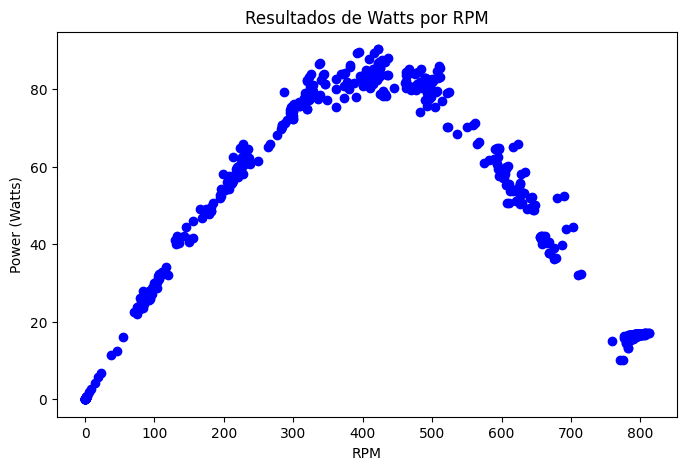

In [ ]:
# Grafica ya sin outliers

plt.figure(figsize=(8,5))
plt.plot(df['RPM_P'], df['Power [Watts]'], marker='o', linestyle='', color='b')
plt.title('Resultados de Watts por RPM')
plt.xlabel('RPM')
plt.ylabel('Power (Watts)')